In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

In [2]:
data = pd.read_csv("games.csv")

In [3]:
data.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [4]:
data.describe()

,AppID,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,1.985386e+06,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,1.087595e+06,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,1.063175e+06,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,1.907380e+06,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,2.869560e+06,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,4.264350e+06,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


In [5]:
n_duplicated = data.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df = pd.DataFrame({
    'n_unique':data.nunique(),
    'n_missing':data.isna().sum(),
    'missing_ratio':data.isna().mean(),
    'dtype':data.dtypes.values
})

Number of duplicated rows: 0



In [6]:
display(
    df.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

,n_unique,n_missing,missing_ratio,dtype
AppID,122611,0,0.00%,int64
Name,121454,1,0.00%,object
Release date,5081,0,0.00%,object
Estimated owners,14,0,0.00%,object
Peak CCU,1110,0,0.00%,int64
Required age,15,0,0.00%,int64
Price,941,0,0.00%,float64
Discount,88,0,0.00%,int64
DLC count,117,0,0.00%,int64
About the game,113556,8449,6.89%,object


In [10]:
data2=data.drop(columns=["Movies","Screenshots","Metacritic url","Header image","AppID","Website","Score rank","Notes",])
data2['About the game'] = data2['About the game'] != ""      #).astype(int) pour quant
data2['Support email'] = data2['Support email'] != ""
data2['Support url'] = data2['Support url'] != ""
data2['Release date'] = data2['Release date'].str[-4:]

# Fonction qui va compter le nombre d'avis dans chaque ligne
def count_reviews(row):
    # S'assurer que chaque ligne est une chaîne de caractères
    if isinstance(row, str):  # Si c'est déjà une chaîne
        reviews = re.findall(r'"([^"]*)"', row)  # Recherche des avis entre guillemets
        return len(reviews)
    else:
        return 0  # Si ce n'est pas une chaîne, retourne 0

# Appliquer la fonction à la colonne 'avis'
data2['Reviews'] = data2['Reviews'].apply(count_reviews)

display(
    data2.head().style.background_gradient(cmap="BuPu")
)
# about the game et suppporturl/email:mettre en qual, changer date de sortie en année de sortie, nb de review

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Support url,Support email,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
0,Black Dragon Mage Playtest,2023,0 - 0,0,0,0.000000,0,0,True,[],[],0,True,True,True,False,False,0,0,0,0,0,0,0,0,0,0,nan,nan,nan,nan,nan
1,Supipara - Chapter 1 Spring Has Come!,2016,0 - 20000,0,0,5.240000,65,0,True,['English'],[],0,True,True,True,False,False,0,0,252,3,0,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
2,Mystery Solitaire The Black Raven,2019,0 - 20000,0,0,4.990000,0,0,True,"['English', 'French', 'German', 'Russian']",[],0,True,True,True,True,False,0,0,21,3,0,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
3,버튜버 파라노이아 - Vtuber Paranoia,2024,0 - 20000,1,0,8.990000,0,1,True,['Korean'],['Korean'],0,True,True,True,False,False,0,0,0,0,19,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",nan
4,Maze Quest VR,2025,0 - 20000,0,0,4.990000,0,0,True,['English'],['English'],0,True,True,True,False,False,0,0,0,0,0,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",nan


In [11]:
data2.loc[data2["Name"].duplicated()]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
1179,Shadow of the Tomb Raider: Definitive Edition,2018,0 - 20000,0,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66724,0,0,0,0,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Lara Croft,Female Protagonist..."
1608,Shadow of the Tomb Raider: Definitive Edition,2018,2000000 - 5000000,582,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66725,1270,304,790,265,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Female Protagonist,Singleplay..."
2411,Last Stop,2023,0 - 20000,0,0,12.99,0,0,True,['English'],...,0,0,0,0,0,Tainted Games,Tainted Games,"Single-player,Steam Achievements,Full controll...","Action,Adventure,Indie","Action,Adventure,Puzzle,Walking Simulator,FPS,..."
3621,Shadow of the Tomb Raider: Definitive Edition,2018,0 - 20000,0,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66731,0,0,0,0,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Lara Croft,Female Protagonist..."
3934,LUNA,2020,50000 - 100000,0,0,0.74,0,0,True,"['English', 'Korean', 'Japanese', 'Simplified ...",...,287,0,0,0,0,Simple,PsychoFlux Entertainment,"Single-player,Steam Achievements,Steam Cloud,F...","Adventure,Casual,Indie,RPG","Puzzle,Female Protagonist,RPG,2D,Top-Down,Horr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122496,FALL,2026,0 - 0,0,0,1.19,0,0,True,['English'],...,0,0,0,0,0,Wise In A Well,Wise In A Well,"Single-player,Custom Volume Controls,Mouse Onl...","Action,Casual,Indie",NaN
122530,Sycophant,2025,0 - 0,0,0,34.99,0,0,True,['Simplified Chinese'],...,0,0,0,0,0,Fractious,Fractious,"Single-player,Family Sharing","Casual,RPG",NaN
122557,Conquest,2026,0 - 0,0,0,3.99,0,0,True,['English'],...,0,0,0,0,0,Zellgert Games,Zellgert Games,"Single-player,Steam Achievements,Camera Comfor...","Adventure,Indie,RPG",NaN
122561,Space Aces,2026,0 - 0,0,0,0.00,0,0,True,['English'],...,0,0,0,0,0,DewEnforcer,Space Aces,"Multi-player,MMO,PvP,Online PvP,Co-op,Online C...","Action,Casual,Massively Multiplayer,Free To Play",NaN


In [12]:
data3 = data2.loc[data2.groupby("Name")["Peak CCU"].idxmax()]
data3.loc[data3["Name"] == "Space Aces"]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
1604,Space Aces,2022,0 - 0,0,0,0.0,0,0,True,['English'],...,0,0,0,0,0,"Matthew Hubbs,Austin Brooks,Bradley Vanderzalm...",Matthew Hubbs,"Single-player,Partial Controller Support","Action,Indie,Simulation",NaN


In [13]:
qual = data3.select_dtypes(exclude='int64')
quant = data3.select_dtypes(include='int64')
display(qual.head())
display(quant.head())

,Name,Release date,Estimated owners,Price,About the game,Supported languages,Full audio languages,Support url,Support email,Windows,Mac,Linux,Developers,Publishers,Categories,Genres,Tags
43895,! Shakabula *,2023,0 - 20000,14.99,True,['English'],[],True,True,True,False,False,Skermunkel,Skermunkel,"Single-player,Full controller support,Steam Cl...","Action,Indie,RPG,Early Access","Early Access,Action,RPG,JRPG,Shooter,Bullet He..."
56348,! That Bastard Is Trying To Steal Our Gold !,2016,50000 - 100000,2.99,True,['English'],[],True,True,True,False,True,WTFOMGames,WTFOMGames,"Single-player,Steam Trading Cards,Partial Cont...","Action,Adventure,Casual,Indie","Puzzle-Platformer,Dark Humor,Dungeon Crawler,M..."
29975,! Wild Russia !,2020,0 - 20000,19.99,True,"['English', 'Simplified Chinese', 'Russian']","['English', 'Simplified Chinese', 'Russian']",True,True,True,False,False,Andreev Worlds,Andreev Worlds,"Single-player,Steam Achievements,Partial Contr...","Action,Adventure,Casual","Adventure,Action,Casual,Horror,Post-apocalypti..."
121733,!AnyWay!,2018,100000 - 200000,1.79,True,"['English', 'Russian', 'French', 'Italian', 'G...",[],True,True,True,False,False,EYEFRONT,EYEFRONT,"Single-player,Multi-player,Steam Achievements,...","Adventure,Casual,Indie","Side Scroller,Precision Platformer,2D Platform..."
64033,!LABrpgUP!,2018,20000 - 50000,0.99,True,['English'],[],True,True,True,False,False,UPandQ,UPandQ,"Single-player,Family Sharing","Adventure,Casual,Indie,RPG","Adventure,Indie,Casual,RPG"


,Peak CCU,Required age,Discount,DLC count,Reviews,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks
43895,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0
56348,0,0,0,0,0,0,0,164,77,0,0,373,0,392,0
29975,0,0,0,0,0,0,0,45,32,9,0,0,0,0,0
121733,2,0,10,39,0,0,0,412,182,4997,496,344,0,374,0
64033,0,0,0,0,0,0,0,26,32,2021,0,0,0,0,0


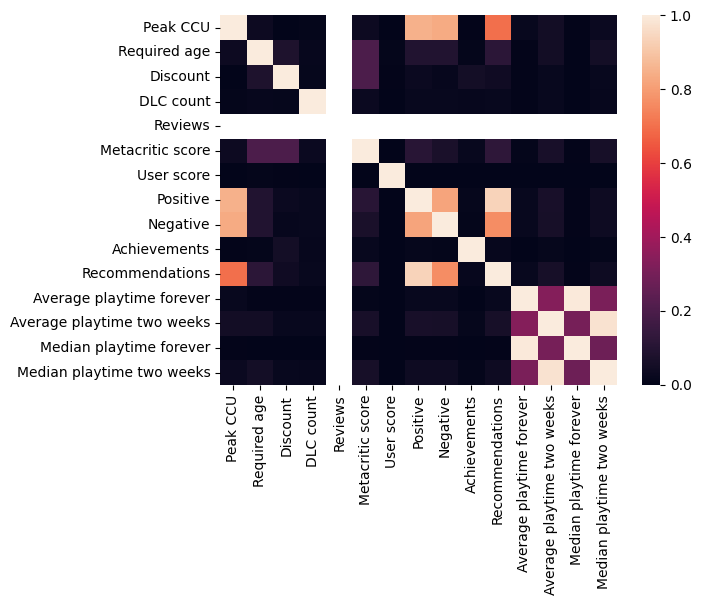

In [14]:
corr=quant.corr()
sns.heatmap(corr)
plt.show()

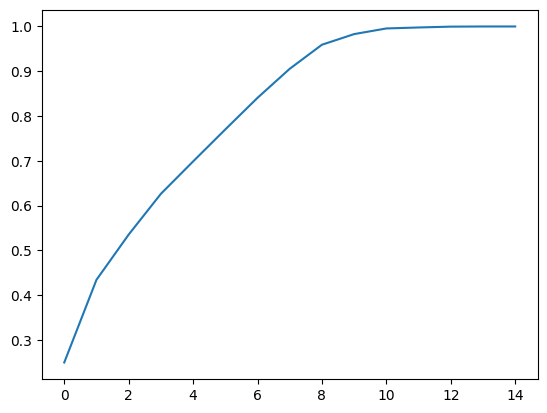

In [15]:
pca = PCA()
## Estimation, calcul des composantes principales
C = pca.fit(scale(quant)).transform(scale(quant))
## Décroissance de la variance expliquée
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.show()

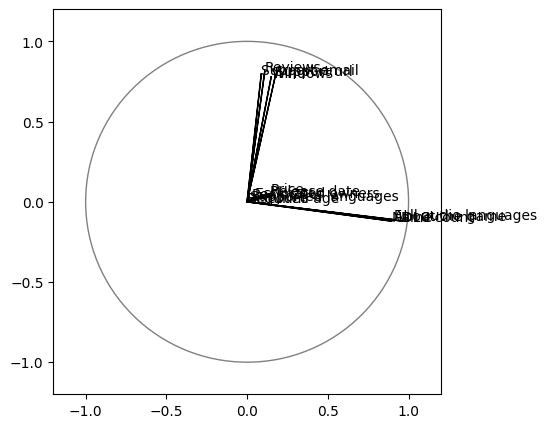

In [16]:
coord1=pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord2=pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1,coord2, data2.columns.values):
    plt.text(i, j, nom)
    plt.arrow(0,0,i,j,color='black')
plt.axis((-1.2,1.2,-1.2,1.2))
# cercle
c=plt.Circle((0,0), radius=1, color='gray', fill=False)
ax.add_patch(c)
plt.show()